# YOLO Digit Detector Training Notebook

This notebook trains and exports the digit detector used in the Smart Meter Reader project.

**Main idea:** train the digit detector on Kaggle instead of locally because image datasets and YOLO training are slow/heavy on normal laptops.

Final training path used in this notebook:

1. Install fixed package versions suitable for Kaggle.
2. Load the YOLO-format digit dataset.
3. Train a YOLOv8n 320×320 teacher model.
4. Create a smaller custom YOLOv8 micro architecture.
5. Train 128×128 and 160×160 micro versions.
6. Export the selected micro model to TFLite / INT8.
7. Test the exported TFLite model visually on real LCD crops.

The final embedded path used the **micro 160 model** exported to TFLite because it gave a better practical balance between size, speed, and detection quality.

# imports

## 1. Kaggle package setup

This cell forces compatible versions of NumPy, OpenCV, and Ultralytics.  
This was needed because Kaggle package updates can sometimes install NumPy 2.x or incompatible OpenCV builds, which may break YOLO/TFLite export.

After running this cell, restart the Kaggle session/kernel before continuing.

In [1]:
import sys, os

# Use the exact Python kernel that Kaggle notebook is running
PY = sys.executable
print("Python:", PY)

# Remove packages that keep pulling NumPy 2.x
!{PY} -m pip uninstall -y ultralytics numpy opencv-python opencv-python-headless opencv-contrib-python

# Install NumPy FIRST
!{PY} -m pip install --no-cache-dir --force-reinstall "numpy==1.26.4"

# Install OpenCV WITHOUT dependencies so it does not upgrade NumPy
!{PY} -m pip install --no-cache-dir --force-reinstall --no-deps "opencv-python-headless==4.10.0.84"

# Install Ultralytics WITHOUT dependencies so it does not touch NumPy/OpenCV
!{PY} -m pip install --no-cache-dir --force-reinstall --no-deps "ultralytics==8.3.40"

# Install missing lightweight dependencies, also without forcing NumPy upgrade
!{PY} -m pip install --no-cache-dir --no-deps pyyaml requests tqdm matplotlib pandas scipy seaborn psutil py-cpuinfo thop pillow

print("Done. Now restart the Kaggle session.")

Python: /usr/bin/python3
Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 315.9 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
easyocr 1.7.2 requires opencv-python-headless, w

In [1]:
import numpy as np
import torch
import torchvision
import cv2

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("torchvision:", torchvision.__version__)
print("opencv:", cv2.__version__)
!pip install ultralytics
from ultralytics import YOLO
print("Ultralytics import OK")

numpy: 2.4.6
torch: 2.10.0+cu128
cuda: True
torchvision: 0.25.0+cu128
opencv: 4.13.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 106.6 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.

## 2. Verify environment

This cell checks the installed versions and confirms CUDA availability.  
Training should be done with GPU enabled in Kaggle to avoid very long local training time.

# yaml update

In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/kaggle/input/datasets/kareemriad025/merged-digit-dataset/merged_digit_dataset")

print("Dataset root exists:", DATASET_ROOT.exists())
print("train images:", (DATASET_ROOT / "train/images").exists())
print("val images:", (DATASET_ROOT / "val/images").exists())
print("test images:", (DATASET_ROOT / "test/images").exists())

fixed_yaml = f"""
path: {DATASET_ROOT}

train: train/images
val: val/images
test: test/images

nc: 11

names:
  0: "0"
  1: "1"
  2: "2"
  3: "3"
  4: "4"
  5: "5"
  6: "6"
  7: "7"
  8: "8"
  9: "9"
  10: "dot"
"""

FIXED_DATA_YAML = Path("/kaggle/working/data_kaggle.yaml")
FIXED_DATA_YAML.write_text(fixed_yaml)

print(FIXED_DATA_YAML.read_text())

## 3. Dataset YAML generation

The dataset is stored in YOLO format with:

- `train/images`
- `val/images`
- `test/images`
- matching YOLO label files
- 11 classes: digits `0`–`9` and `dot`

The generated `data_kaggle.yaml` tells Ultralytics where the dataset is inside the Kaggle environment.

# Training Yolov8

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"

model = YOLO("yolov8n.pt")

model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=320,
    batch=16,
    patience=25,
    device=0,
    workers=2,
    project="/kaggle/working/runs_digit_detector",
    name="yolov8n_digits_320",
    pretrained=True,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    mosaic=0.3,
    close_mosaic=20,
    plots=True
)

best = Path("/kaggle/working/runs_digit_detector/yolov8n_digits_320/weights/best.pt")
print("Best model:", best)
print("Exists:", best.exists())
print("Size MB:", best.stat().st_size / (1024 * 1024) if best.exists() else "missing")

## 4. YOLOv8n 320×320 teacher training

This was the first stronger model used to check that the dataset and labels are valid.  
It uses the standard pretrained `yolov8n.pt` model at image size 320.

This model is useful for accuracy testing, but it is too heavy for the ESP32-CAM final embedded deployment.

In [ ]:
best = Path("/kaggle/working/runs_digit_detector/yolov8n_digits_320/weights/best.pt")
print("Best model:", best)
print("Exists:", best.exists())
print("Size MB:", best.stat().st_size / (1024 * 1024) if best.exists() else "missing")

# Exporting this YOLOv8n teacher to TFLite

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"

MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8n_digits_320/weights/best.pt"

model = YOLO(MODEL_PATH)

exported = model.export(
    format="tflite",
    imgsz=320,
    int8=True,
    data=DATA_YAML
)

exported = Path(str(exported))
print("Exported:", exported)

if exported.exists():
    size_kb = exported.stat().st_size / 1024
    print("TFLite size KB:", size_kb)
    print("TFLite size MB:", size_kb / 1024)

!find /kaggle/working -name "*.tflite"

## 5. Export the 320 model to TFLite

This export was tested to understand the TFLite pipeline, but the resulting model was still too large/heavy for the final ESP32-CAM implementation.

# Test predictions visually 

In [ ]:
from ultralytics import YOLO

MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8n_digits_320/weights/best.pt"
TEST_IMAGES = "/kaggle/input/datasets/kareemriad025/sd-pulls"

model = YOLO(MODEL_PATH)

model.predict(
    source=TEST_IMAGES,
    imgsz=320,
    conf=0.25,
    save=True,
    project="/kaggle/working/predictions",
    name="yolov8n_test"
)


!ls /kaggle/working/predictions/yolov8n_test | head

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

pred_dir = Path("/kaggle/working/predictions/yolov8n_test")
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Found prediction images:", len(imgs))

for img_path in imgs[:56]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

### Micro yaml creation 

In [ ]:
micro_yaml = r"""
nc: 11

backbone:
  - [-1, 1, Conv, [8, 3, 2]]
  - [-1, 1, Conv, [16, 3, 2]]
  - [-1, 1, C2f, [16, True]]
  - [-1, 1, Conv, [32, 3, 2]]
  - [-1, 1, C2f, [32, True]]
  - [-1, 1, Conv, [48, 3, 2]]
  - [-1, 1, C2f, [48, True]]
  - [-1, 1, SPPF, [48, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 1, C2f, [32]]

  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 2], 1, Concat, [1]]
  - [-1, 1, C2f, [16]]

  - [[13], 1, Detect, [nc]]
"""

with open("/kaggle/working/yolov8_digits_micro.yaml", "w") as f:
    f.write(micro_yaml)

print("Created:")
print("/kaggle/working/yolov8_digits_micro.yaml")

print("\nFile content:")
print(open("/kaggle/working/yolov8_digits_micro.yaml").read())

## 6. Custom micro YOLO architecture

This cell defines a much smaller YOLO-like architecture with fewer channels than YOLOv8n.

The goal is to reduce:

- model size
- RAM usage
- tensor arena requirement
- inference cost on ESP32-CAM

This is the key transition from the laptop/Kaggle model toward an embedded model.

# Training Mirco YOLO

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"

model = YOLO("/kaggle/working/yolov8_digits_micro.yaml")

model.train(
    data=DATA_YAML,
    epochs=250,
    imgsz=128,
    batch=64,
    patience=50,
    device=0,
    workers=2,
    project="/kaggle/working/runs_digit_detector",
    name="yolov8_digits_micro_128",
    pretrained=False,
    optimizer="AdamW",
    lr0=0.002,
    cos_lr=True,
    warmup_epochs=5,
    mosaic=0.4,
    close_mosaic=40,
    plots=True
)

best = Path("/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best.pt")
print("Best model:", best)
print("Exists:", best.exists())
print("Size MB:", best.stat().st_size / (1024 * 1024) if best.exists() else "missing")

## 7. Train micro YOLO at 128×128

This was the first very small embedded-friendly experiment.  
It reduces memory and computation, but the lower input resolution can make small digit detection harder.

# Validate the micro model

In [ ]:
from ultralytics import YOLO

DATA_YAML = "/kaggle/working/data_kaggle.yaml"
MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best.pt"

micro_model = YOLO(MODEL_PATH)

metrics = micro_model.val(
    data=DATA_YAML,
    imgsz=128,
    device=0
)

print(metrics)

# Export micro model to INT8 TFLite

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"
MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best.pt"

micro_model = YOLO(MODEL_PATH)

exported = micro_model.export(
    format="tflite",
    imgsz=128,
    int8=True,
    data=DATA_YAML
)

exported = Path(str(exported))
print("Exported:", exported)

if exported.exists():
    size_kb = exported.stat().st_size / 1024
    print("TFLite size KB:", size_kb)
    print("TFLite size MB:", size_kb / 1024)

    if size_kb <= 512:
        print("SUCCESS: under 512 KB")
    else:
        print("Still above 512 KB")

!find /kaggle/working -name "*.tflite"

# micro 160 version


In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"

model = YOLO("/kaggle/working/yolov8_digits_micro.yaml")

model.train(
    data=DATA_YAML,
    epochs=250,
    imgsz=160,
    batch=64,
    patience=50,
    device=0,
    workers=2,
    project="/kaggle/working/runs_digit_detector",
    name="yolov8_digits_micro_160",
    pretrained=False,
    optimizer="AdamW",
    lr0=0.002,
    cos_lr=True,
    warmup_epochs=5,
    mosaic=0.35,
    close_mosaic=40,
    plots=True
)

## 8. Train micro YOLO at 160×160

This became the preferred final training direction.  
Compared with 128×128, 160×160 keeps more digit detail while still being much lighter than the 320×320 teacher model.

# Export micro 160

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/kaggle/working/data_kaggle.yaml"
MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_160/weights/best.pt"

micro_model = YOLO(MODEL_PATH)

exported = micro_model.export(
    format="tflite",
    imgsz=160,
    int8=True,
    data=DATA_YAML
)

exported = Path(str(exported))
print("Exported:", exported)

if exported.exists():
    size_kb = exported.stat().st_size / 1024
    print("TFLite size KB:", size_kb)
    print("TFLite size MB:", size_kb / 1024)

    if size_kb <= 512:
        print("SUCCESS: under 512 KB")
    else:
        print("Still above 512 KB")

!find /kaggle/working -name "*.tflite"

## 9. Export micro 160 model to TFLite / INT8

This is the important export stage for deployment.  
The exported `.tflite` file is later converted/embedded into the Arduino sketch as a C array/header file, then loaded by the TensorFlow Lite Micro-compatible inference code on the ESP32-CAM.

# test visually on .pt


In [ ]:
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best.pt"
TEST_IMAGES = "/kaggle/input/datasets/kareemriad025/merged-digit-dataset/merged_digit_dataset/test/images"

model = YOLO(MODEL_PATH)

results = model.predict(
    source=TEST_IMAGES,
    imgsz=128,
    conf=0.20,
    iou=0.45,
    save=True,
    project="/kaggle/working/predictions",
    name="micro_pt_test"
)

print("Saved predictions to:")
print("/kaggle/working/predictions/micro_pt_test")

!ls /kaggle/working/predictions/micro_pt_test | head

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

pred_dir = Path("/kaggle/working/predictions/micro_pt_test")
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Found prediction images:", len(imgs))

for img_path in imgs[:56]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

# .tflite

In [ ]:
from ultralytics import YOLO
from pathlib import Path

TFLITE_MODEL = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best_saved_model/best_int8.tflite"
TEST_IMAGES = "/kaggle/input/datasets/kareemriad025/merged-digit-dataset/merged_digit_dataset/test/images"

tflite_model = YOLO(TFLITE_MODEL)

results = tflite_model.predict(
    source=TEST_IMAGES,
    imgsz=128,
    conf=0.20,
    iou=0.45,
    save=True,
    project="/kaggle/working/predictions",
    name="micro_tflite_test"
)

print("Saved TFLite predictions to:")
print("/kaggle/working/predictions/micro_tflite_test")

!ls /kaggle/working/predictions/micro_tflite_test | head

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

pred_dir = Path("/kaggle/working/predictions/micro_tflite_test")
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Found prediction images:", len(imgs))

for img_path in imgs[40:56]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

In [ ]:
from ultralytics import YOLO

DATA_YAML = "/kaggle/working/data_kaggle.yaml"
TFLITE_MODEL = "/kaggle/working/runs_digit_detector/yolov8_digits_micro_128/weights/best_saved_model/best_int8.tflite"

model = YOLO(TFLITE_MODEL)

metrics = model.val(
    data=DATA_YAML,
    imgsz=128,
    device=0,
    int8=True
)

print(metrics)

# real test

In [2]:
from ultralytics import YOLO

TFLITE_MODEL = "/kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite"
REAL_IMAGE = "/kaggle/input/datasets/kareemriad025/lcd-crops"  # change path

model = YOLO(TFLITE_MODEL)

model.predict(
    source=REAL_IMAGE,
    imgsz=160,
    conf=0.15,
    iou=0.45,
    agnostic_nms=True,
    save=True,
    project="/kaggle/working/predictions",
    name="real_crops_tflite"
)
print("Saved predictions to:")
print("/kaggle/working/predictions/real_crops_tflite")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.


E0000 00:00:1781007706.935125      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781007706.987663      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781007707.452639      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781007707.452679      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781007707.452682      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781007707.452685      58 computation_placer.cc:177] computation placer already registered. Please check linka

Loading /kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite for TensorFlow Lite inference...

image 1/40 /kaggle/input/datasets/kareemriad025/lcd-crops/Screenshot 2026-06-09 151003_edited.png: 160x160 1 3, 1 6, 1 7, 1 dot, 16.2ms
image 2/40 /kaggle/input/datasets/kareemriad025/lcd-crops/Screenshot 2026-06-09 151451_edited.png: 160x160 1 3, 1 7, 1 9, 7.3ms
image 3/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_0001.bmp: 160x160 5 0s, 1 6, 7.4ms
image 4/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_0002.bmp: 160x160 1 0, 1 2, 1 5, 1 6, 7.2ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


image 5/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_0003.bmp: 160x160 1 0, 1 1, 3 6s, 3 8s, 6.9ms
image 6/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_0004.bmp: 160x160 2 0s, 2 3s, 1 6, 1 7, 2 8s, 6.7ms
image 7/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_001.bmp: 160x160 1 0, 2 5s, 1 7, 6.9ms
image 8/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_0015.bmp: 160x160 2 1s, 1 2, 1 6, 1 7, 1 9, 7.3ms
image 9/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_002.bmp: 160x160 4 0s, 1 1, 1 5, 2 6s, 6.4ms
image 10/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_003.bmp: 160x160 2 0s, 1 1, 1 5, 2 6s, 2 8s, 7.3ms
image 11/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_004.bmp: 160x160 2 0s, 2 3s, 1 7, 2 8s, 1 9, 9.2ms
image 12/40 /kaggle/input/datasets/kareemriad025/lcd-crops/crop_005.bmp: 160x160 2 0s, 2 3s, 1 7, 2 8s, 1 9, 7.2ms
image 13/40 /kaggle/input/datasets/kareemriad025/lcd-crops/full_0015.jpg: 160x160 (no detections), 7.0ms
ima

## 10. Test exported TFLite on real LCD crops

This section tests the exported TFLite model on real ESP32-CAM LCD crops, not only on the clean dataset.

This matters because real camera images contain blur, compression artifacts, reflections, and crop shifts.

Found prediction images: 40


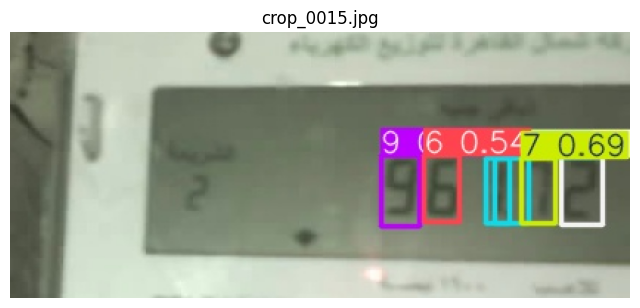

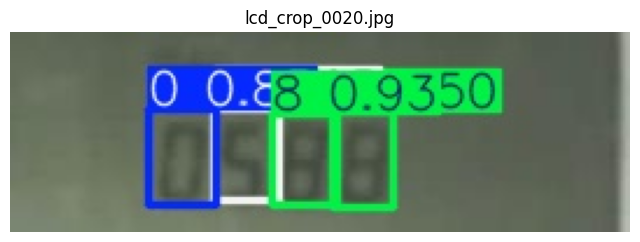

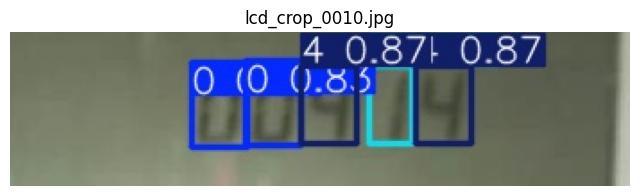

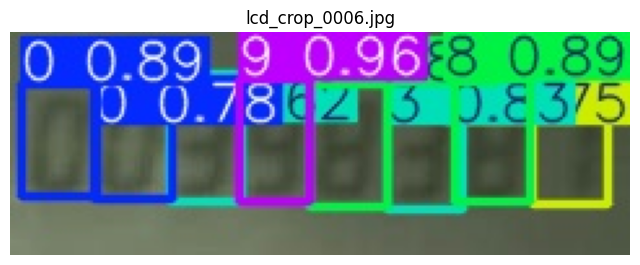

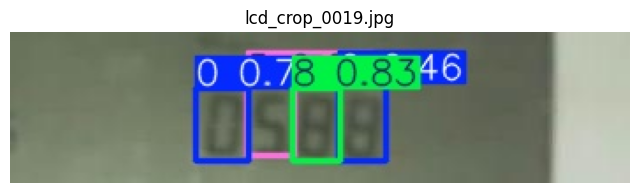

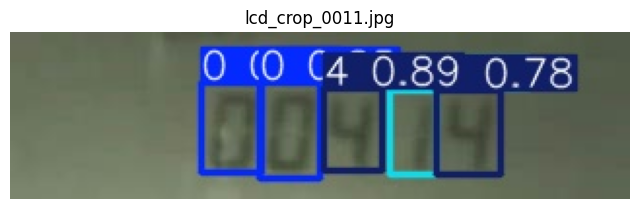

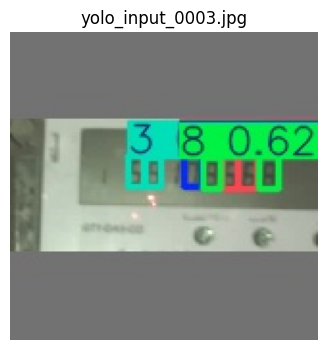

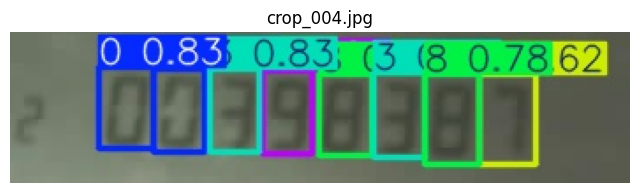

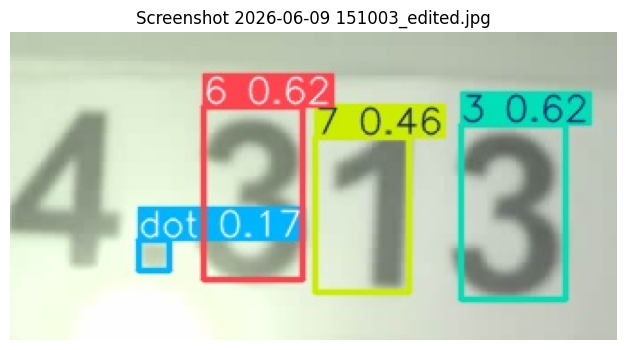

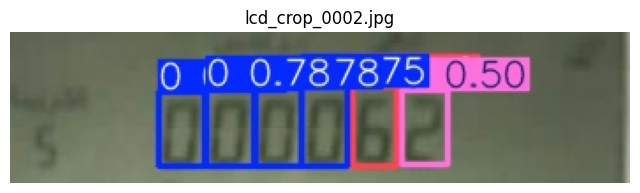

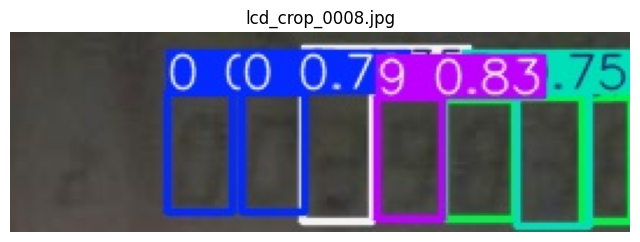

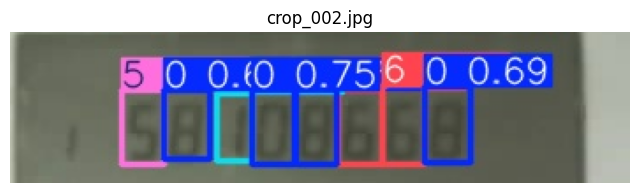

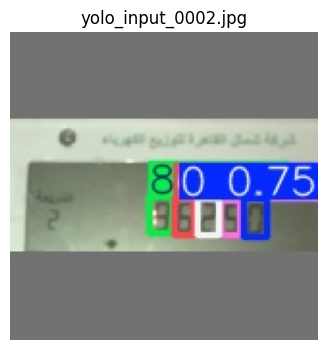

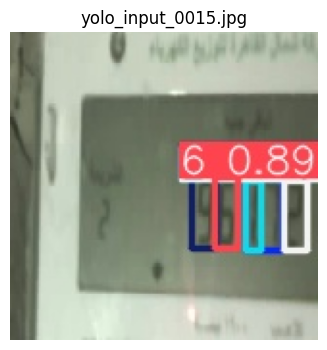

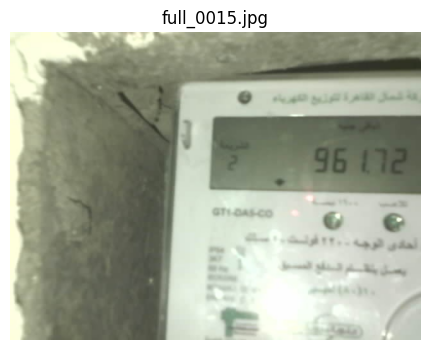

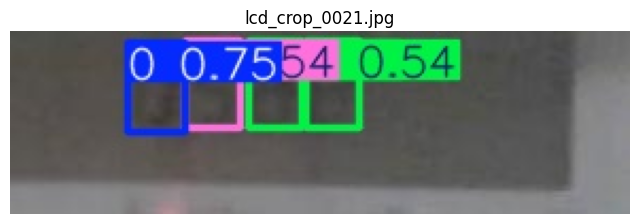

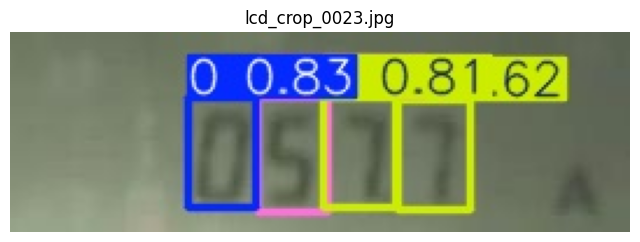

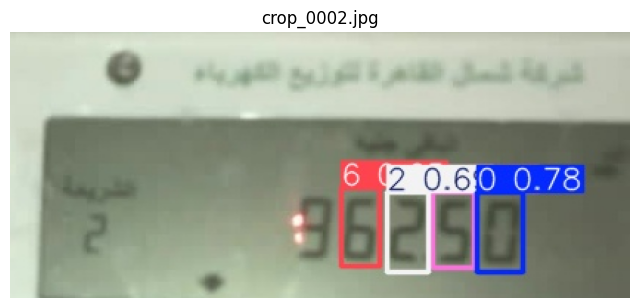

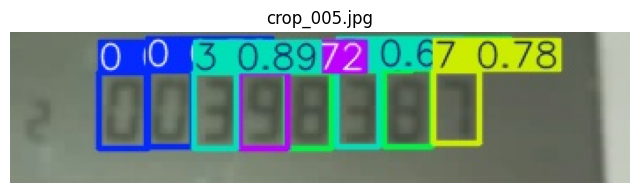

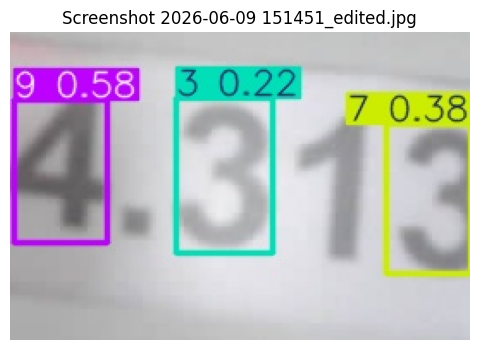

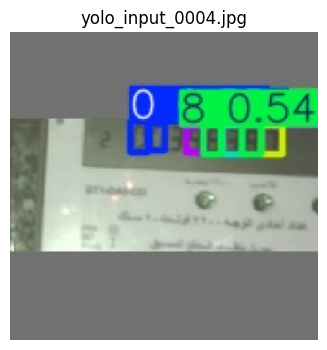

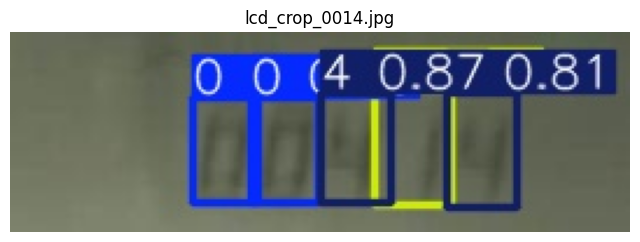

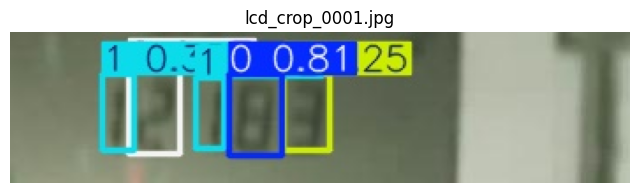

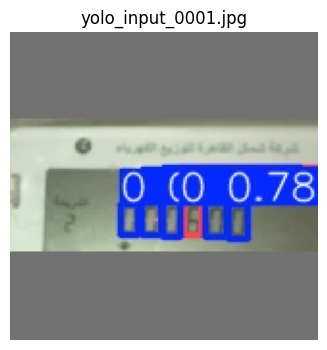

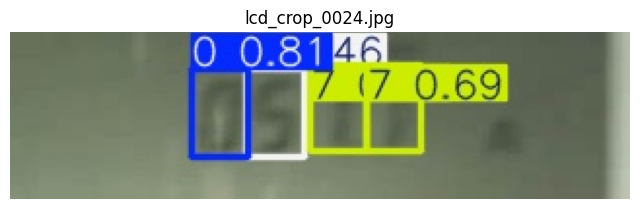

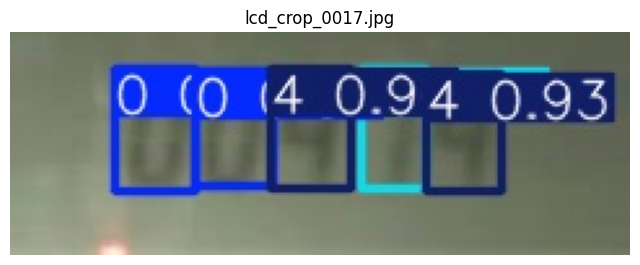

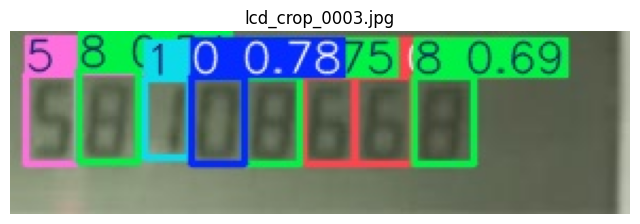

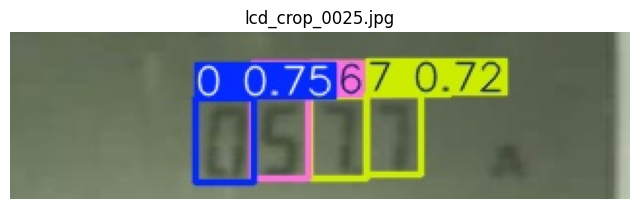

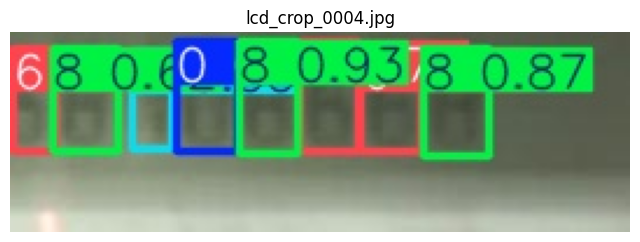

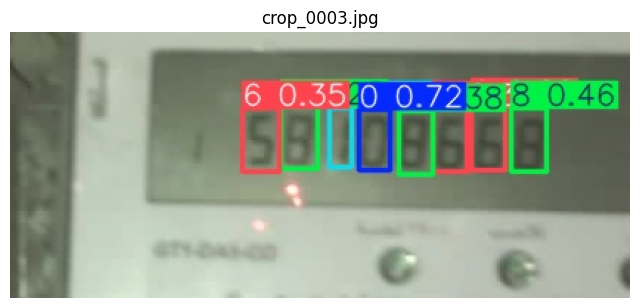

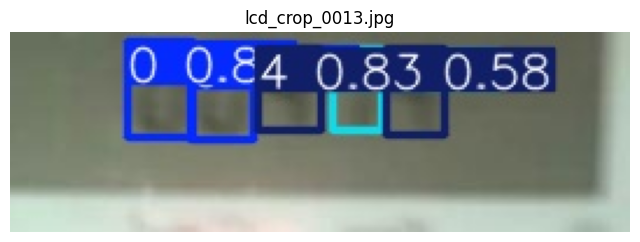

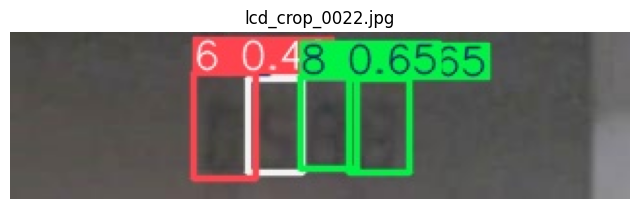

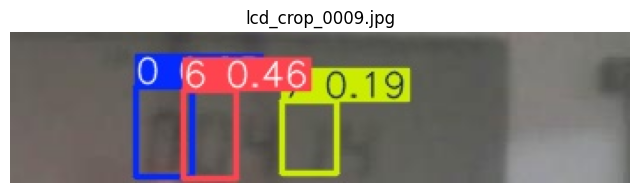

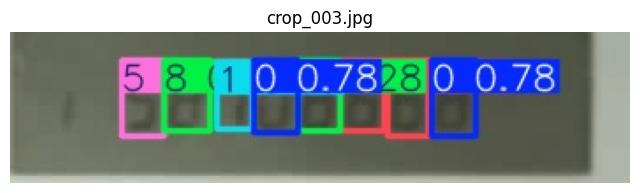

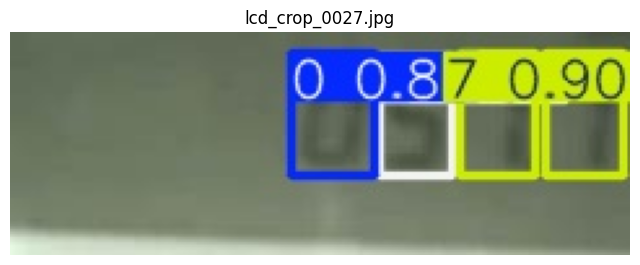

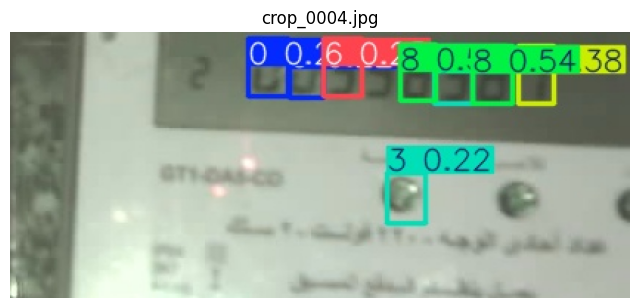

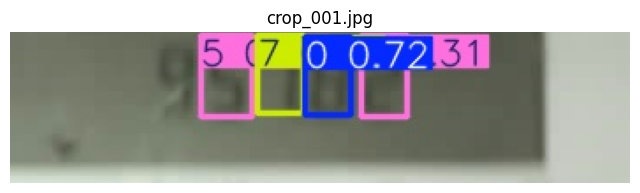

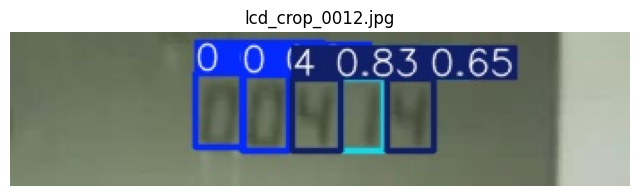

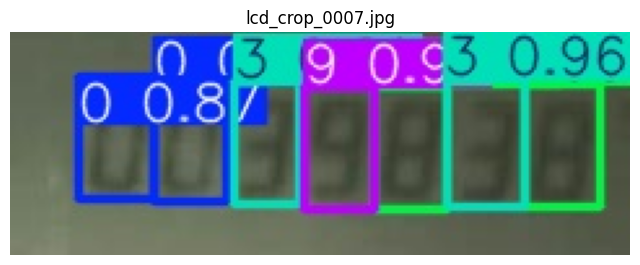

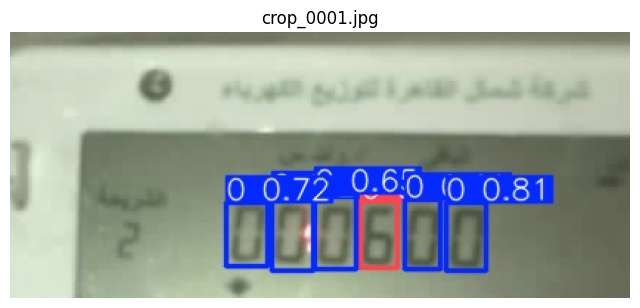

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

pred_dir = Path("/kaggle/working/predictions/real_crops_tflite")
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Found prediction images:", len(imgs))

for img_path in imgs[:40]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    .
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

## enhancement

In [12]:
import cv2
from pathlib import Path

def enhance_lcd_crop_v2(input_path, output_path):
    img = cv2.imread(str(input_path))
    if img is None:
        raise FileNotFoundError(input_path)

    # 1. FIXED SCALE: Upscale equally (4x) on both axes to maintain correct proportions
    # This prevents the digits from looking unnaturally wide or squished
    height, width = img.shape[:2]
    upscaled = cv2.resize(img, (width * 4, height * 4), interpolation=cv2.INTER_LANCZOS4)

    # 2. LAB Color adjustment
    lab = cv2.cvtColor(upscaled, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Moderate CLAHE so we don't amplify blocky sensor noise
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    enhanced = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

    # 3. EDGE PRESERVING SMOOTHING (Replaces harsh sharpening)
    # This removes the blocky ESP32 compression lines but keeps the digit outlines sharp
    smoothed = cv2.bilateralFilter(enhanced, d=7, sigmaColor=50, sigmaSpace=50)

    # 4. Subtle contrast push
    gray = cv2.cvtColor(smoothed, cv2.COLOR_BGR2GRAY)
    
    cv2.imwrite(str(output_path), gray)

# Run the updated function
enhance_lcd_crop_v2(
    "/kaggle/input/datasets/kareemriad025/lcd-crops/lcd_crop_0001.jpg",
    "/kaggle/working/lcd_crop_0001_enhanced.jpg"
)


## 11. Optional enhancement experiments

These cells test image enhancement ideas such as upscaling, CLAHE, and smoothing.  
They are kept for documentation and future improvement, but the final embedded implementation should avoid expensive preprocessing unless required.

Found prediction images: 1


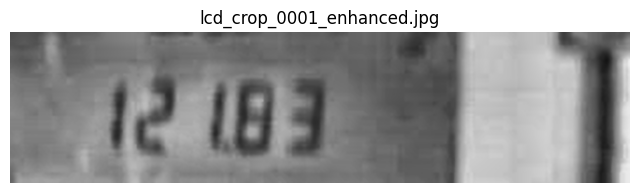

In [13]:
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

pred_dir = Path("/kaggle/working")
imgs = list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png"))

print("Found prediction images:", len(imgs))

for img_path in imgs[:2]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

# digit Test

In [3]:
from ultralytics import YOLO

CLASS_NAMES = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "dot"]

MODEL_PATH = "/kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite"
IMAGE_PATH = "/kaggle/input/datasets/kareemriad025/lcd-crops/Screenshot 2026-06-09 151003_edited.png"
#IMAGE_PATH = "/kaggle/working/lcd_crop_0007_enhanced.jpg"
model = YOLO(MODEL_PATH)

results = model.predict(
    source=IMAGE_PATH,
    imgsz=160,
    conf=0.15,
    iou=0.45,
    verbose=False,
    agnostic_nms=True
)

r = results[0]

detections = []

for box in r.boxes:
    cls_id = int(box.cls[0].item())
    conf = float(box.conf[0].item())

    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cx = (x1 + x2) / 2

    detections.append({
        "label": CLASS_NAMES[cls_id],
        "conf": conf,
        "cx": cx,
        "box": [x1, y1, x2, y2]
    })

detections = sorted(detections, key=lambda d: d["cx"])

reading = ""

for d in detections:
    if d["label"] == "dot":
        reading += "."
    else:
        reading += d["label"]

print("Detections:")
for d in detections:
    print(d)

print("Reading:", reading)

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite for TensorFlow Lite inference...
Detections:
{'label': 'dot', 'conf': 0.17130500078201294, 'cx': 80.03446960449219, 'box': [71.50621032714844, 115.31834411621094, 88.56272888183594, 132.37486267089844]}
{'label': '6', 'conf': 0.619033932685852, 'cx': 135.1401710510254, 'box': [107.58731842041016, 41.84407424926758, 162.69302368164062, 137.62303161621094]}
{'label': '7', 'conf': 0.45940884947776794, 'cx': 195.4940414428711, 'box': [169.9092559814453, 58.900611877441406, 221.07882690429688, 144.1832275390625]}
{'label': '3', 'conf': 0.619033932685852, 'cx': 279.4646301269531, 'box': [250.5997314453125, 51.68437194824219, 308.32952880859375,

## 12. Detection post-processing experiments

These cells sort detections left-to-right and test confidence/row filtering.

The same idea is used in the final ESP32-CAM sketch:

1. detect digit boxes
2. remove low-confidence detections
3. remove detections outside the main digit row
4. sort remaining boxes by x-position
5. construct the final reading string

In [26]:
from ultralytics import YOLO 
MODEL_PATH = "/kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best.pt"

model = YOLO(MODEL_PATH)
print(model.info())

YOLOv8_digits_micro summary: 70 layers, 118,243 parameters, 0 gradients, 3.6 GFLOPs
(70, 118243, 0, 3.5859456)


# conf + filtering

In [8]:
from ultralytics import YOLO
import numpy as np

CLASS_NAMES = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "dot"]

MODEL_PATH = "/kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite"
IMAGE_PATH = "/kaggle/input/datasets/kareemriad025/lcd-crops/crop_0015.bmp"

model = YOLO(MODEL_PATH)

results = model.predict(
    source=IMAGE_PATH,
    imgsz=160,
    conf=0.15,
    iou=0.45,
    verbose=False,
    agnostic_nms=True
)

r = results[0]

detections = []

for box in r.boxes:
    cls_id = int(box.cls[0].item())
    conf_score = float(box.conf[0].item())

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = x2 - x1
    bh = y2 - y1

    detections.append({
        "label": CLASS_NAMES[cls_id],
        "conf": conf_score,
        "cx": cx,
        "cy": cy,
        "w": bw,
        "h": bh,
        "box": [x1, y1, x2, y2]
    })

# 1) Remove boxes that are too huge or too tiny
if detections:
    heights = [d["h"] for d in detections]
    median_h = np.median(heights)

    detections = [
        d for d in detections
        if d["h"] >= 0.45 * median_h and d["h"] <= 1.45 * median_h
    ]

# 2) Keep only boxes on the same horizontal digit row
if detections:
    median_y = np.median([d["cy"] for d in detections])
    median_h = np.median([d["h"] for d in detections])

    detections = [
        d for d in detections
        if abs(d["cy"] - median_y) <= 0.45 * median_h
    ]

# 3) Sort left to right
detections = sorted(detections, key=lambda d: d["cx"])

reading = ""

for d in detections:
    reading += "." if d["label"] == "dot" else d["label"]

print("Detections:")
for d in detections:
    print(d)

print("Reading:", reading)

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading /kaggle/input/notebooks/kareemriad025/yolo-digit-detector/runs_digit_detector/yolov8_digits_micro_160/weights/best_saved_model/best_full_integer_quant.tflite for TensorFlow Lite inference...
Detections:
{'label': '9', 'conf': 0.24917089939117432, 'cx': 264.8998107910156, 'cy': 107.53041076660156, 'w': 26.1629638671875, 'h': 47.42034912109375, 'box': [251.81832885742188, 83.82023620605469, 277.9812927246094, 131.24058532714844]}
{'label': '6', 'conf': 0.5411680340766907, 'cx': 292.6979217529297, 'cy': 105.89521408081055, 'w': 24.527740478515625, 'h': 45.785133361816406, 'box': [280.4340515136719, 83.00264739990234, 304.9617919921875, 128.78778076171875]}
{'label': '1', 'conf': 0.5411680340766907, 'cx': 330.3071746826172, 'cy': 107.53041076660156, 'w': 16.351837158203125, 'h': 44.14996337890625,